<a href="https://colab.research.google.com/github/ddoneu/FinalProject-Employee-Attrition-Prediction/blob/main/Final%20Submission/Final_Project_Dat_Do.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECON 3916 Final Project: Employee Attrition Prediction
### Author: Dat Do

#1st Checkpoint - April 19

## **PART 1: PROPOSAL**

1. **Prediction question:** Can we predict whether an employee will voluntarily leave the organization based on their demographic, compensation, and job-satisfaction characteristics?

2. **Prediction vs. causation:** This is a prediction task, not causal inference. Feature importance scores reflect predictive associations, not causal effects. For example, if "OverTime" is a strong predictor, that does not mean eliminating overtime would necessarily reduce attrition, there may be confounders such as job role or workload that drive both.

3. **Dataset:** IBM HR Analytics Employee Attrition Dataset from Kaggle (https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset), N = 1,470 employees, 35 columns total, 34 predictors plus the binary target Attrition (Yes/No).

This dataset is well-suited to the stakeholder's decision for three reasons:


*   First, it captures the exact dimensions an HR director would act on
compensation, satisfaction scores, overtime load, and tenure, rather than generic demographic proxies.

   
* Second, the predictors span multiple intervention levers, including scheduling, compensation, satisfaction, and career development, so the model output can map to retention programs rather than a single undifferentiated risk score.

* Third, with 1,470 labeled records and a known 16% attrition rate, the dataset is large enough to train and evaluate a reasonable baseline classifier while the class imbalance mirrors what HR teams actually face in practice, making the model's behavior realistic rather than artificially optimistic.



4. **Stakeholder:** An HR director at a mid-size firm deciding which employee segments to target with retention programs (flexible scheduling, compensation adjustments, career development), prioritizing segments where predicted attrition risk is highest and intervention cost is lowest.

## **PART 2: Exploratory Data Analysis**

In [1]:
#Set up environment

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve)

In [2]:
#Load data from Kaggle

!pip install -q kagglehub

import kagglehub
import pandas as pd

path = kagglehub.dataset_download("pavansubhasht/ibm-hr-analytics-attrition-dataset")
df = pd.read_csv(path + "/WA_Fn-UseC_-HR-Employee-Attrition.csv")

print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns\n")


#Describe the Data (shape, dtypes)
print("DATA TYPES:")
for dtype, count in df.dtypes.value_counts().items():
    print(f"  {dtype}: {count} columns")

df.describe().round(2)

Using Colab cache for faster access to the 'ibm-hr-analytics-attrition-dataset' dataset.
Dataset shape: 1,470 rows × 35 columns

DATA TYPES:
  int64: 26 columns
  object: 9 columns


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.00,1470.00,1470.00,1470.00,1470.0,1470.00,1470.00,1470.00,1470.00,1470.00,...,1470.00,1470.0,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00
mean,36.92,802.49,9.19,2.91,1.0,1024.87,2.72,65.89,2.73,2.06,...,2.71,80.0,0.79,11.28,2.80,2.76,7.01,4.23,2.19,4.12
std,9.14,403.51,8.11,1.02,0.0,602.02,1.09,20.33,0.71,1.11,...,1.08,0.0,0.85,7.78,1.29,0.71,6.13,3.62,3.22,3.57
min,18.00,102.00,1.00,1.00,1.0,1.00,1.00,30.00,1.00,1.00,...,1.00,80.0,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
25%,30.00,465.00,2.00,2.00,1.0,491.25,2.00,48.00,2.00,1.00,...,2.00,80.0,0.00,6.00,2.00,2.00,3.00,2.00,0.00,2.00
50%,36.00,802.00,7.00,3.00,1.0,1020.50,3.00,66.00,3.00,2.00,...,3.00,80.0,1.00,10.00,3.00,3.00,5.00,3.00,1.00,3.00
75%,43.00,1157.00,14.00,4.00,1.0,1555.75,4.00,83.75,3.00,3.00,...,4.00,80.0,1.00,15.00,3.00,3.00,9.00,7.00,3.00,7.00
max,60.00,1499.00,29.00,5.00,1.0,2068.00,4.00,100.00,4.00,5.00,...,4.00,80.0,3.00,40.00,6.00,4.00,40.00,18.00,15.00,17.00


In [3]:
# Missing data check (MCAR/MAR/MNAR Framework)
missing_counts = df.isna().sum().sort_values(ascending=False)
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    'missing_count': missing_counts,
    'missing_pct': missing_pct
})

if missing_counts.sum() == 0:
    print("Dataset completeness: 100%")
    print()
    print("-> No missing values detected.")
    print("-> MCAR/MAR/MNAR classification is not applicable because there is no observed missingness.")
    print("-> No imputation strategy is needed.")
else:
    print(missing_summary[missing_summary['missing_count'] > 0])

print(f"\nTotal missing values: {missing_counts.sum()}")

Dataset completeness: 100%

-> No missing values detected.
-> MCAR/MAR/MNAR classification is not applicable because there is no observed missingness.
-> No imputation strategy is needed.

Total missing values: 0


                      Lower Fence  Upper Fence  Outlier Count  Outlier %
Feature                                                                 
MonthlyIncome             -5291.0      16581.0            114        7.8
TotalWorkingYears            -7.5         28.5             63        4.3
YearsAtCompany               -6.0         18.0            104        7.1
YearsWithCurrManager         -5.5         14.5             14        1.0
YearsInCurrentRole           -5.5         14.5             21        1.4
Age                          10.5         62.5              0        0.0
DistanceFromHome            -16.0         32.0              0        0.0
NumCompaniesWorked           -3.5          8.5             52        3.5


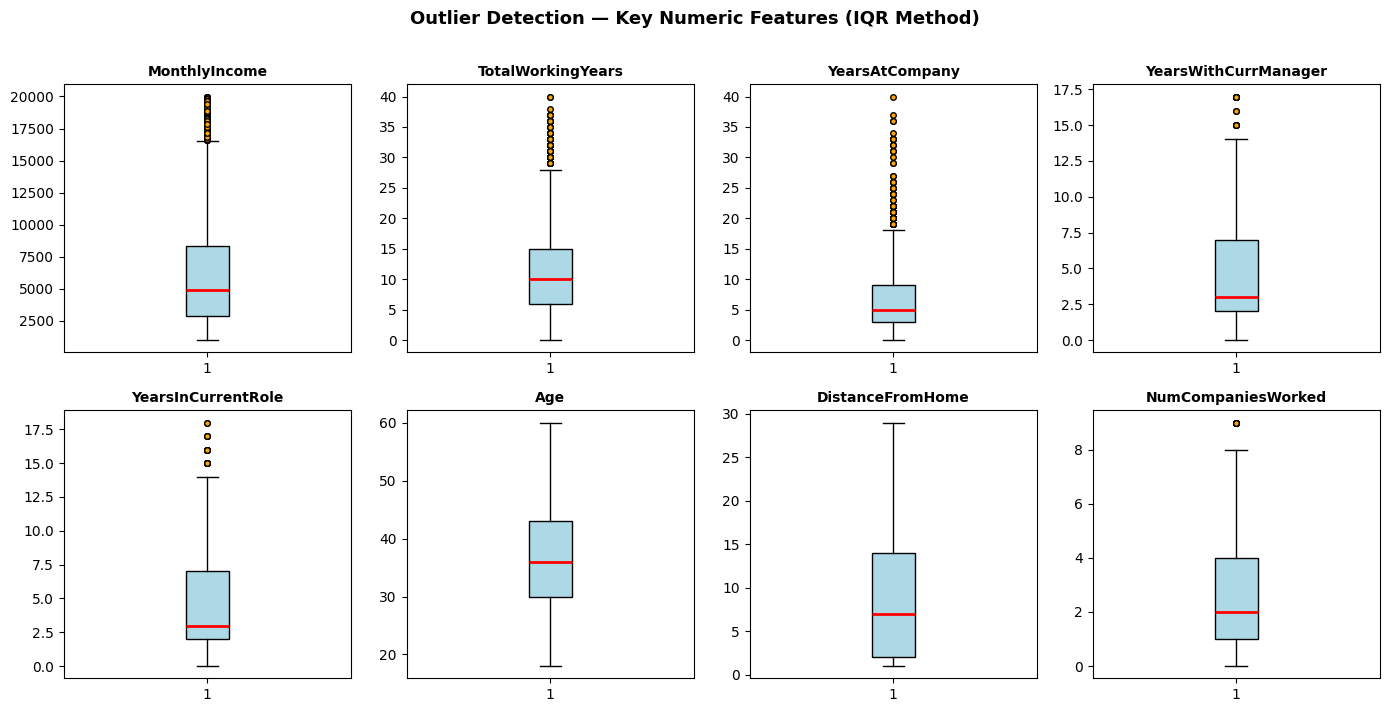

In [4]:
# Outlier Assessment (IQR Method — Ch. 4)
num_cols_outlier = ['MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany','YearsWithCurrManager', 'YearsInCurrentRole', 'Age', 'DistanceFromHome', 'NumCompaniesWorked']

outlier_summary = []
for col in num_cols_outlier:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_outliers = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    outlier_summary.append({
        'Feature': col,
        'Lower Fence': round(Q1 - 1.5*IQR, 1),
        'Upper Fence': round(Q3 + 1.5*IQR, 1),
        'Outlier Count': n_outliers,
        'Outlier %': round(n_outliers / len(df) * 100, 1)
    })

print(pd.DataFrame(outlier_summary).set_index('Feature').to_string())

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()
for i, col in enumerate(num_cols_outlier):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='lightblue'),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', markerfacecolor='orange', markersize=4))
    axes[i].set_title(col, fontweight='bold', fontsize=10)
plt.suptitle('Outlier Detection — Key Numeric Features (IQR Method)',
             fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**Interpretation Outlier Assessment:**
Using the IQR method from Chapter 4, several features show upper-tail outliers, most notably MonthlyIncome, YearsAtCompany, TotalWorkingYears, and NumCompaniesWorked. These reflect genuine workforce heterogeneity such as senior executives and frequent job-changers rather than data entry errors. All records are retained, as removing them would discard real predictive signal at the senior end of the workforce.

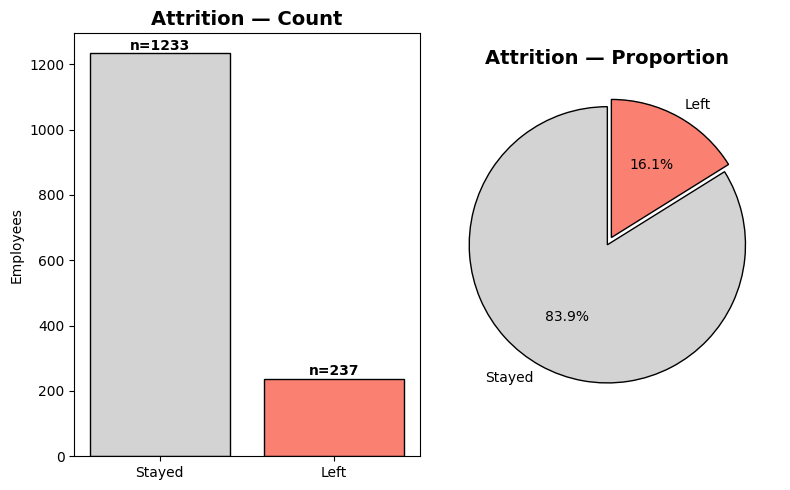

Attrition rate: 16.1%
Class imbalance present — will prioritize recall & F1 over accuracy.


In [5]:
# Visual 1: Attrition Distribution
fig, axes = plt.subplots(1, 2, figsize=(8, 5))

# Use consistent visual meaning:
# Stayed / No = light gray
# Left / Yes = salmon/red
counts = df['Attrition'].value_counts().reindex(['No', 'Yes'])
colors = ['lightgray', 'salmon']

# Bar chart
bars = axes[0].bar(['Stayed', 'Left'], counts.values, color=colors, edgecolor='black')
axes[0].set_title('Attrition — Count', fontweight='bold', fontsize=14)
axes[0].set_ylabel('Employees')

for bar, val in zip(bars, counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        val + 12,
        f'n={val}',
        ha='center',
        fontweight='bold'
    )

# Pie chart
pct = df['Attrition'].value_counts(normalize=True).reindex(['No', 'Yes']) * 100
axes[1].pie(
    pct.values,
    labels=['Stayed', 'Left'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    explode=(0, 0.06),
    wedgeprops={'edgecolor': 'black'}
)

axes[1].set_title('Attrition — Proportion', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.show()

print(f"Attrition rate: {pct['Yes']:.1f}%")
print("Class imbalance present — will prioritize recall & F1 over accuracy.")

**Interpretation**: About 16% of employees left while roughly 84% stayed, so the target variable is clearly imbalanced. This means a naive model that predicts “Stayed” for everyone would appear accurate but would fail to identify actual leavers. As a result, recall and F1-score will be more informative than accuracy when evaluating attrition models.


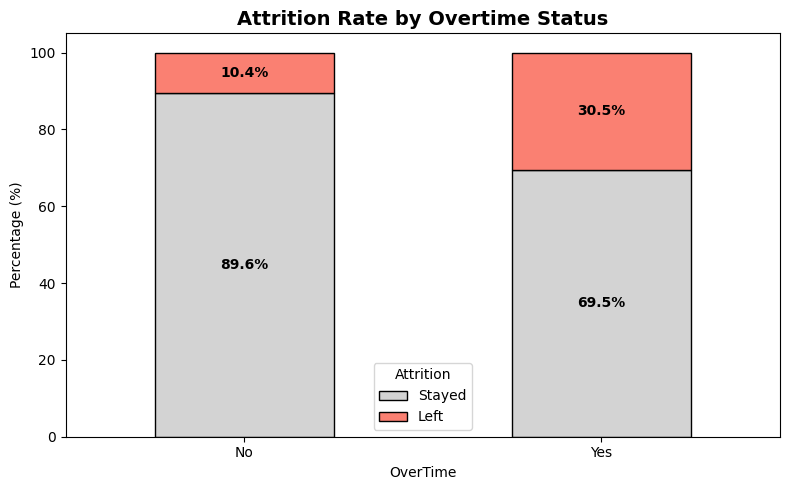

In [6]:
# Visual 2: Attrition by Overtime
fig, ax = plt.subplots(figsize=(8, 5))

ct = pd.crosstab(df['OverTime'], df['Attrition'], normalize='index') * 100


# Plot Stayed first, Left second
ct[['No', 'Yes']].plot(
    kind='bar',
    stacked=True,
    color=['lightgray', 'salmon'],
    edgecolor='black',
    ax=ax
)

ax.set_title('Attrition Rate by Overtime Status', fontweight='bold', fontsize=14)
ax.set_ylabel('Percentage (%)')
ax.set_xlabel('OverTime')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Attrition', labels=['Stayed', 'Left'])

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        label_type='center',
        fontweight='bold',
        color='black'
    )

plt.tight_layout()
plt.show()

**Interpretation**: Employees who work overtime have an attrition rate of 30.5%, compared with only 10.4% for those who do not. This suggests that Overtime is likely one of the strongest predictive features in the dataset. However, this should be interpreted as a predictive association rather than evidence that overtime itself causes attrition.

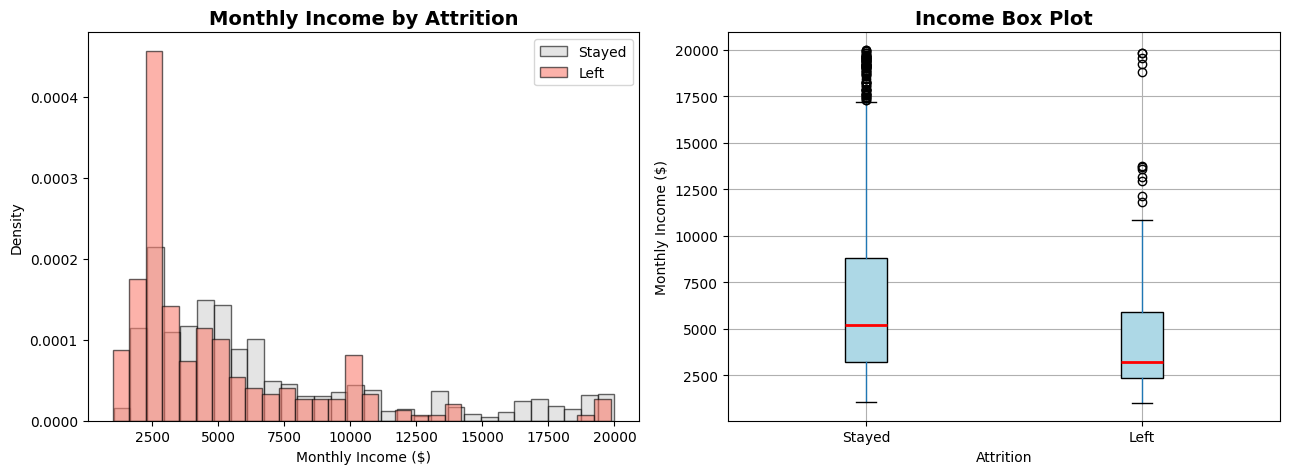


            count    mean     std     min     25%     50%     75%      max
Attrition                                                                 
No         1233.0  6833.0  4818.0  1051.0  3211.0  5204.0  8834.0  19999.0
Yes         237.0  4787.0  3640.0  1009.0  2373.0  3202.0  5916.0  19859.0


In [7]:
#Visualization 3: Monthly income by attrition
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram using density because the two attrition groups have different sample sizes
for label, color, display_label in zip(
    ['No', 'Yes'],
    ['lightgray', 'salmon'],
    ['Stayed', 'Left']
):
    axes[0].hist(
        df[df['Attrition'] == label]['MonthlyIncome'],
        bins=30,
        alpha=0.6,
        density=True,
        label=display_label,
        color=color,
        edgecolor='black'
    )

axes[0].set_title('Monthly Income by Attrition', fontweight='bold', fontsize=14)
axes[0].set_xlabel('Monthly Income ($)')
axes[0].set_ylabel('Density')
axes[0].legend()


# Box plot
df.boxplot(column='MonthlyIncome', by='Attrition', ax=axes[1], patch_artist=True, boxprops=dict(facecolor='lightblue'), medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Income Box Plot', fontweight='bold', fontsize=14)
axes[1].set_xticklabels(['Stayed', 'Left'])
axes[1].set_ylabel('Monthly Income ($)')
plt.suptitle('')

plt.tight_layout()
plt.show()

print()
print('=='*40)

print(df.groupby('Attrition')['MonthlyIncome'].describe().round(0))

**Interpretation:** Employees who left the company have a lower median monthly income than those who stayed. The density histogram suggests that employees who left are relatively more concentrated in the lower-income range, and the box plot confirms a noticeable gap in medians between the two groups. This implies that compensation is likely a useful predictive feature for attrition, although this pattern should be interpreted as association rather than causal evidence.

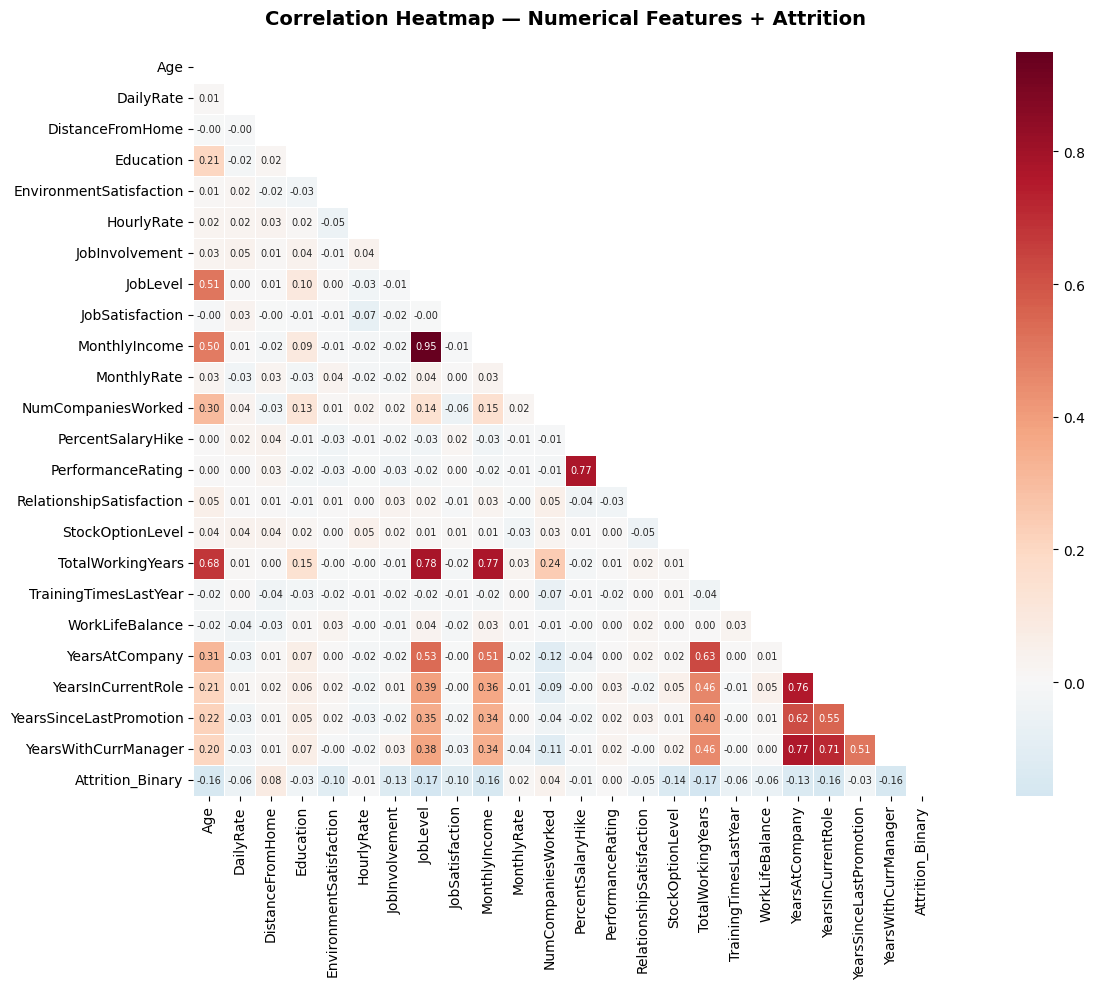

In [8]:
#Visualization 4: Correlation heatmap
num_cols = [c for c in df.select_dtypes(include=[np.number]).columns
            if c not in ['EmployeeCount', 'StandardHours', 'EmployeeNumber']]
df_corr = df[num_cols].copy()
df_corr['Attrition_Binary'] = (df['Attrition'] == 'Yes').astype(int)
corr = df_corr.corr()

fig, ax = plt.subplots(figsize=(16, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax, annot_kws={'size': 7})
ax.set_title('Correlation Heatmap — Numerical Features + Attrition',
             fontweight='bold', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

In [9]:
# Signed correlations with Attrition, ranked by absolute strength
signed_corr = corr['Attrition_Binary'].drop('Attrition_Binary')
signed_ranked = signed_corr.reindex(
    signed_corr.abs().sort_values(ascending=False).index
)

print("\nTop 10 signed correlations with Attrition, ranked by absolute strength:")
print(signed_ranked.head(10).round(3))


Top 10 signed correlations with Attrition, ranked by absolute strength:
TotalWorkingYears      -0.171
JobLevel               -0.169
YearsInCurrentRole     -0.161
MonthlyIncome          -0.160
Age                    -0.159
YearsWithCurrManager   -0.156
StockOptionLevel       -0.137
YearsAtCompany         -0.134
JobInvolvement         -0.130
JobSatisfaction        -0.103
Name: Attrition_Binary, dtype: float64


**Interpretation:** The correlation heatmap displays pairwise relationships across numerical features, while the signed correlation output shows the direction and strength of each feature's relationship with Attrition.

TotalWorkingYears, JobLevel, YearsInCurrentRole, MonthlyIncome, and Age have the strongest negative correlations with attrition meaning employees who are earlier in their careers, lower-paid, and younger are more likely to leave in this dataset. The individual correlations are modest, so the model likely needs to combine multiple weak signals rather than rely on one dominant predictor. These relationships should be interpreted as predictive associations, not causal effects.

### Data Quality Summary:

The dataset is relatively clean and suitable for predictive modeling. It contains 1,470 employee records and the target variable, Attrition, is clearly defined as a binary outcome.

I checked for missing values and found no observed missingness, so no imputation or row deletion was required. This reduces the risk of bias from missing-data handling and allows the full sample to be retained.

The main data-quality concern is class imbalance: only about 16% of employees left, while about 84% stayed. This means model evaluation should prioritize recall, precision, and F1-score rather than relying only on accuracy. The EDA also suggests that attrition is associated with several employee characteristics, including overtime status, monthly income, age, and tenure-related variables, so the prediction task likely depends on combining multiple signals rather than one dominant feature. Overall, the dataset appears complete, structured, and appropriate for a binary classification project.

##**PART 3: PRELIMINARY MODEL**

In [10]:
# Drop constant & noninformative columns
drop_cols = ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber']
df_model = df.drop(columns=drop_cols).copy()

# Encode target: Yes → 1, No → 0
df_model['Attrition'] = (df_model['Attrition'] == 'Yes').astype(int)

# One-hot encode categorical features
cat_cols = df_model.select_dtypes(include=['object']).columns.tolist()
df_encoded = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)

print(f"Features after encoding: {df_encoded.shape[1] - 1}")

Features after encoding: 44


In [11]:
#Train/Test Split
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

X = df_encoded.drop(columns=['Attrition'])
y = df_encoded['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples | Attrition rate: {y_train.mean():.1%}")
print(f"Test set:     {X_test.shape[0]} samples | Attrition rate: {y_test.mean():.1%}")

Training set: 1176 samples | Attrition rate: 16.2%
Test set:     294 samples | Attrition rate: 16.0%


In [12]:
#Logistic Regression Baseline
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

y_pred = log_reg.predict(X_test_scaled)

print(classification_report(y_test, y_pred, target_names=['Stayed', 'Left']))
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")

              precision    recall  f1-score   support

      Stayed       0.88      0.96      0.92       247
        Left       0.62      0.34      0.44        47

    accuracy                           0.86       294
   macro avg       0.75      0.65      0.68       294
weighted avg       0.84      0.86      0.84       294

Accuracy:  0.8605
Precision: 0.6154
Recall:    0.3404
F1 Score:  0.4384


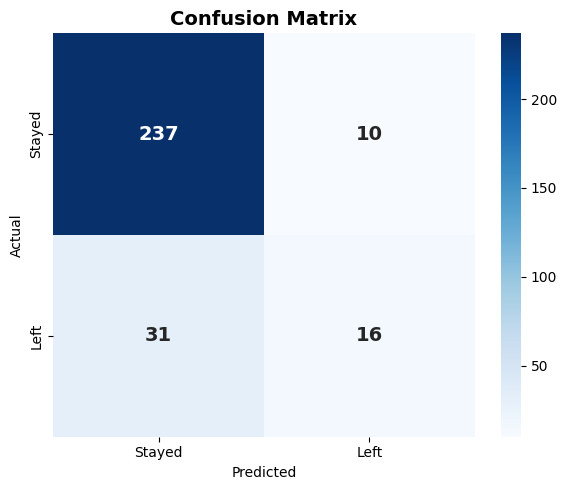

In [13]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Stayed', 'Left'], yticklabels=['Stayed', 'Left'], ax=ax, annot_kws={'size': 14, 'fontweight': 'bold'})
ax.set_title('Confusion Matrix', fontweight='bold', fontsize=14)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

**Preliminary Model Summary:**

As an initial benchmark, I fit a logistic regression model using an 80/20 train-test split with random_state=42 and stratify=y to preserve the attrition rate in both samples. Because logistic regression is simple, interpretable, and widely used for binary classification, it serves as a useful baseline before moving to more flexible machine learning models. I standardized the predictors with StandardScaler so the model could estimate coefficients on a comparable scale and converge more reliably.

A key challenge in this dataset is class imbalance: only about 16% of employees left, while roughly 84% stayed. This means accuracy alone is not an adequate performance measure, since a naïve classifier that predicts “Stayed” for every employee would already achieve around 84% accuracy while completely failing to identify actual leavers. For this reason, I place more weight on recall and F1-score for the “Left” class, because the practical goal is to flag employees who are at risk of attrition rather than simply maximize overall correctness on the majority class.

The confusion matrix and classification report provide a clearer picture of model performance by showing not only how often the model is correct, but also whether it is missing too many true attrition cases. This is especially important in an HR setting, where false negatives may be costly because they represent employees the firm fails to identify as retention risks.

However, the baseline logistic model still misses 31 of the 47 actual leavers in the test set. Therefore, it should not be used as an automatic decision rule. It is better interpreted as a risk-screening tool that helps HR prioritize follow-up conversations, not as a final yes/no intervention system.



#Final Deliverables April 26

##**PART 4: FINAL MODELING: Logistic Regression vs. Random Forest**

In [14]:
#Import additional libraries for RF and CV

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import make_pipeline
import warnings
warnings.filterwarnings('ignore')

print('Setup complete ✓')

Setup complete ✓


I use Random Forest as the second model because it can capture nonlinear relationships and interactions that Logistic Regression may miss. I set `n_estimators=200` to reduce variance relative to a smaller forest while keeping the model simple and reproducible. No heavy hyperparameter tuning is done here because the goal is a transparent comparison between a simple interpretable model and a more flexible machine learning model.

In [15]:
# Train Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print('Random Forest fitted ✓')

Random Forest fitted ✓


Note on preprocessing: LR predictions below use X_test_scaled (the test set transformed by the scaler fit on training data only). RF predictions use unscaled X_test because tree-based models do not require feature scaling. Both are consistent with each model's preprocessing requirements and no data leakage is introduced.


In [16]:
# Compare both models on the held-out test set
results = []
for name, y_pred_m in [('Logistic Regression', y_pred), ('Random Forest', y_pred_rf)]:
    results.append({
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_test, y_pred_m), 4),
        'Precision': round(precision_score(y_test, y_pred_m, zero_division=0), 4),
        'Recall':    round(recall_score(y_test, y_pred_m), 4),
        'F1':        round(f1_score(y_test, y_pred_m), 4),
        'AUC':       round(roc_auc_score(y_test,
                        log_reg.predict_proba(X_test_scaled)[:, 1]
                        if name == 'Logistic Regression'
                        else rf.predict_proba(X_test)[:, 1]), 4)
    })

print(pd.DataFrame(results).set_index('Model').to_string())

                     Accuracy  Precision  Recall      F1     AUC
Model                                                           
Logistic Regression    0.8605     0.6154  0.3404  0.4384  0.8079
Random Forest          0.8265     0.3333  0.0851  0.1356  0.8009


In [17]:
# Bootstrap 95% Confidence Intervals (1000 iterations)

def bootstrap_ci(y_true, y_pred, metric_fn, n_boot=1000, seed=42):
    rng = np.random.default_rng(seed)
    scores = []
    for _ in range(n_boot):
        idx = rng.integers(0, len(y_true), len(y_true))
        scores.append(metric_fn(y_true[idx], y_pred[idx]))
    lower = np.percentile(scores, 2.5)
    upper = np.percentile(scores, 97.5)
    return np.mean(scores), lower, upper

y_true_arr = y_test.values

metrics_boot = {
    'Accuracy':  lambda yt, yp: accuracy_score(yt, yp),
    'Precision': lambda yt, yp: precision_score(yt, yp, zero_division=0),
    'Recall':    lambda yt, yp: recall_score(yt, yp, zero_division=0),
    'F1':        lambda yt, yp: f1_score(yt, yp, zero_division=0),
}

ci_rows = []

for label, fn in metrics_boot.items():
    lr_mean, lr_lo, lr_hi = bootstrap_ci(y_true_arr, y_pred, fn)
    rf_mean, rf_lo, rf_hi = bootstrap_ci(y_true_arr, y_pred_rf, fn)

    ci_rows.append({
        "Model": "Logistic Regression",
        "Metric": label,
        "Mean": round(lr_mean, 4),
        "95% CI Lower": round(lr_lo, 4),
        "95% CI Upper": round(lr_hi, 4)
    })

    ci_rows.append({
        "Model": "Random Forest",
        "Metric": label,
        "Mean": round(rf_mean, 4),
        "95% CI Lower": round(rf_lo, 4),
        "95% CI Upper": round(rf_hi, 4)
    })

ci_table = pd.DataFrame(ci_rows)
ci_table

,Model,Metric,Mean,95% CI Lower,95% CI Upper
0,Logistic Regression,Accuracy,0.8610,0.8230,0.8980
1,Random Forest,Accuracy,0.8277,0.7857,0.8707
2,Logistic Regression,Precision,0.6144,0.4091,0.8000
3,Random Forest,Precision,0.3371,0.0769,0.6364
4,Logistic Regression,Recall,0.3390,0.2036,0.4773
5,Random Forest,Recall,0.0855,0.0189,0.1750
6,Logistic Regression,F1,0.4333,0.2856,0.5714
7,Random Forest,F1,0.1345,0.0322,0.2667


In [18]:
# Bootstrap 95% Confidence Intervals for AUC

def bootstrap_auc_ci(y_true, y_prob, n_boot=1000, seed=42):
    rng = np.random.default_rng(seed)
    scores = []

    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)

    for _ in range(n_boot):
        idx = rng.integers(0, len(y_true), len(y_true))

        # AUC is undefined if a bootstrap sample contains only one class
        if len(np.unique(y_true[idx])) < 2:
            continue

        scores.append(roc_auc_score(y_true[idx], y_prob[idx]))

    lower = np.percentile(scores, 2.5)
    upper = np.percentile(scores, 97.5)

    return np.mean(scores), lower, upper


lr_auc_mean, lr_auc_lo, lr_auc_hi = bootstrap_auc_ci(
    y_true_arr,
    log_reg.predict_proba(X_test_scaled)[:, 1]
)

rf_auc_mean, rf_auc_lo, rf_auc_hi = bootstrap_auc_ci(
    y_true_arr,
    rf.predict_proba(X_test)[:, 1]
)

print("Bootstrap 95% Confidence Intervals — AUC")
print(f"Logistic Regression AUC: {lr_auc_mean:.4f} [{lr_auc_lo:.4f}, {lr_auc_hi:.4f}]")
print(f"Random Forest AUC:       {rf_auc_mean:.4f} [{rf_auc_lo:.4f}, {rf_auc_hi:.4f}]")

Bootstrap 95% Confidence Intervals — AUC
Logistic Regression AUC: 0.8086 [0.7301, 0.8791]
Random Forest AUC:       0.8021 [0.7310, 0.8673]


In [19]:
#5-Fold Stratified Cross-Validation

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_pipeline = make_pipeline(
    StandardScaler(),
    LogisticRegression(random_state=42, max_iter=1000)
)

lr_f1_scores = cross_val_score(
    lr_pipeline, X_train, y_train, cv=cv, scoring='f1'
)

rf_f1_scores = cross_val_score(
    RandomForestClassifier(n_estimators=200, random_state=42),
    X_train, y_train, cv=cv, scoring='f1'
)

print(f'LR  5-fold CV F1: {lr_f1_scores.mean():.4f} +/- {lr_f1_scores.std():.4f}')
print(f'Per-fold: {lr_f1_scores.round(4)}')
print()
print(f'RF  5-fold CV F1: {rf_f1_scores.mean():.4f} +/- {rf_f1_scores.std():.4f}')
print(f'Per-fold: {rf_f1_scores.round(4)}')

LR  5-fold CV F1: 0.5552 +/- 0.0884
Per-fold: [0.5263 0.4    0.6129 0.6562 0.5806]

RF  5-fold CV F1: 0.3044 +/- 0.0834
Per-fold: [0.2326 0.186  0.4167 0.3404 0.3462]


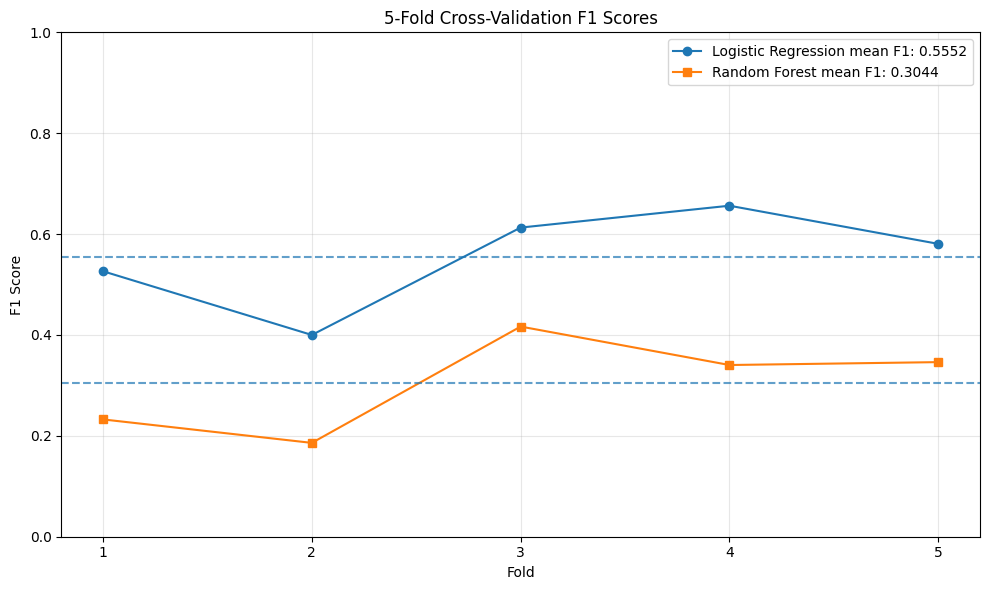

In [20]:
# CV F1 scores across folds with mean reference lines

plt.figure(figsize=(10, 6))

folds = range(1, 6)

plt.plot(folds, lr_f1_scores, marker='o', label=f'Logistic Regression mean F1: {lr_f1_scores.mean():.4f}')
plt.plot(folds, rf_f1_scores, marker='s', label=f'Random Forest mean F1: {rf_f1_scores.mean():.4f}')

plt.axhline(lr_f1_scores.mean(), linestyle='--', alpha=0.7)
plt.axhline(rf_f1_scores.mean(), linestyle='--', alpha=0.7)

plt.title('5-Fold Cross-Validation F1 Scores')
plt.xlabel('Fold')
plt.ylabel('F1 Score')
plt.xticks(folds)
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The 5-fold stratified cross-validation results support Logistic Regression as the preferred model. Logistic Regression has a higher F1-score than Random Forest in every fold, with a mean CV F1 of 0.5552 compared with 0.3044 for Random Forest. Because F1 balances precision and recall for the minority attrition class, this result is more relevant than accuracy alone.

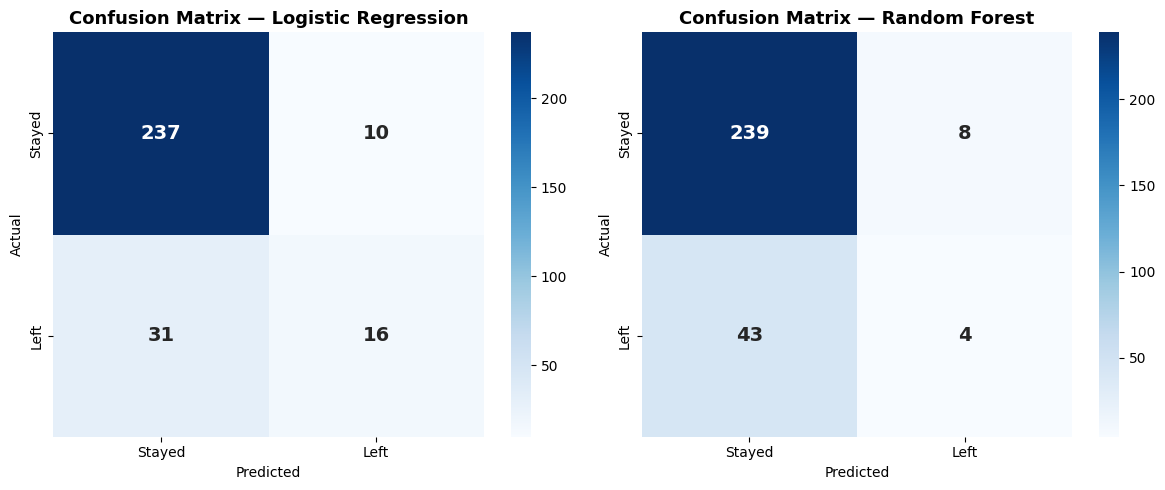

In [21]:
# Confusion matrices

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, y_pred_m) in zip(axes, [
    ('Logistic Regression', y_pred),
    ('Random Forest',       y_pred_rf)
]):
    cm_m = confusion_matrix(y_test, y_pred_m)
    sns.heatmap(cm_m, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Stayed', 'Left'],
                yticklabels=['Stayed', 'Left'],
                ax=ax, annot_kws={'size': 14, 'fontweight': 'bold'})
    ax.set_title(f'Confusion Matrix — {name}', fontweight='bold', fontsize=13)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

### Final Model Selection

Logistic Regression is selected as the preferred model. It outperforms Random Forest on the held-out test set across accuracy, precision, recall, F1-score, and AUC. The difference is especially important for recall and F1-score: Logistic Regression identifies more actual leavers, while Random Forest is too conservative and misses most attrition cases.

The cross-validation results also support this choice. Logistic Regression has a higher mean 5-fold CV F1-score than Random Forest and performs better in every fold. Because attrition is an imbalanced classification problem, F1-score and recall are more relevant than accuracy alone. Therefore, Logistic Regression is the better final model for this project, although its recall remains limited and should be improved through threshold tuning before real HR deployment.

### Threshold and Recommendation

The default 0.50 classification threshold is conservative. In this test set, Logistic Regression identifies 16 of the 47 actual leavers but misses 31. Because false negatives represent employees who leave without being flagged, future versions should evaluate lower probability thresholds. A lower threshold would likely increase recall, though at the cost of more false positives.

For HR decision-making, this tradeoff may be acceptable if the intervention is low-cost and non-punitive, such as a manager check-in, career development conversation, or workload review. The model should be used to prioritize outreach, not to make automatic employment decisions.

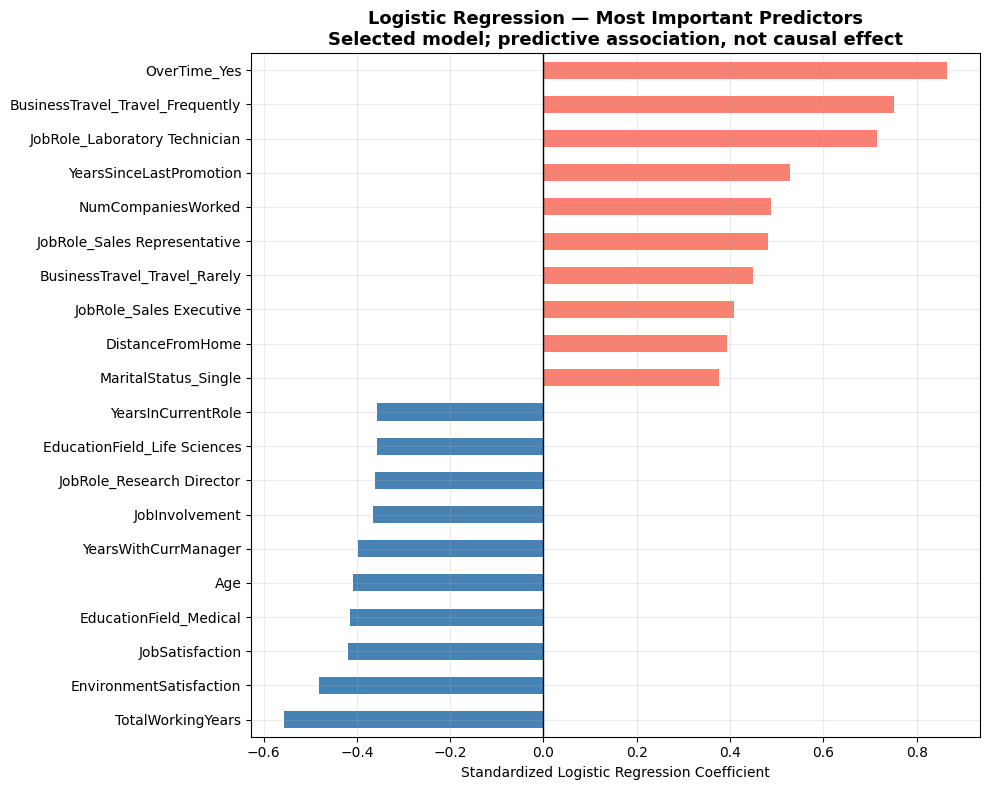


Top 10 positive predictors of attrition risk:
OverTime_Yes                        0.8646
BusinessTravel_Travel_Frequently    0.7512
JobRole_Laboratory Technician       0.7148
YearsSinceLastPromotion             0.5287
NumCompaniesWorked                  0.4876
JobRole_Sales Representative        0.4815
BusinessTravel_Travel_Rarely        0.4501
JobRole_Sales Executive             0.4094
DistanceFromHome                    0.3936
MaritalStatus_Single                0.3769
dtype: float64

Top 10 negative predictors of attrition risk:
TotalWorkingYears              -0.5556
EnvironmentSatisfaction        -0.4817
JobSatisfaction                -0.4194
EducationField_Medical         -0.4145
Age                            -0.4076
YearsWithCurrManager           -0.3984
JobInvolvement                 -0.3653
JobRole_Research Director      -0.3613
EducationField_Life Sciences   -0.3562
YearsInCurrentRole             -0.3560
dtype: float64


In [22]:
# Logistic Regression Coefficient Importance for Selected Model

coef_importance = pd.Series(
    log_reg.coef_[0],
    index=X_train.columns
).sort_values()

top_negative = coef_importance.head(10)
top_positive = coef_importance.tail(10)

top_coef = pd.concat([top_negative, top_positive])

fig, ax = plt.subplots(figsize=(10, 8))

top_coef.plot.barh(ax=ax, color=['steelblue' if x < 0 else 'salmon' for x in top_coef])

ax.axvline(0, color='black', linewidth=1)
ax.set_title(
    'Logistic Regression — Most Important Predictors\nSelected model; predictive association, not causal effect',
    fontweight='bold',
    fontsize=13
)
ax.set_xlabel('Standardized Logistic Regression Coefficient')
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

print("\nTop 10 positive predictors of attrition risk:")
print(coef_importance.sort_values(ascending=False).head(10).round(4))

print("\nTop 10 negative predictors of attrition risk:")
print(coef_importance.sort_values(ascending=True).head(10).round(4))

Because Logistic Regression is the selected final model, its standardized coefficients provide the main model-based interpretation. Positive coefficients indicate features associated with higher predicted attrition risk, while negative coefficients indicate features associated with lower predicted attrition risk. Since the predictors were standardized before fitting the model, the coefficient magnitudes are more comparable across variables than raw unscaled coefficients.

These coefficients should still be interpreted as predictive associations, not causal effects. For example, if OverTime_Yes has a positive coefficient, that means overtime helps predict attrition risk in this dataset, but it does not prove that overtime itself causes employees to leave. The coefficient plot is therefore useful for understanding the model’s prediction logic, not for making causal policy claims.

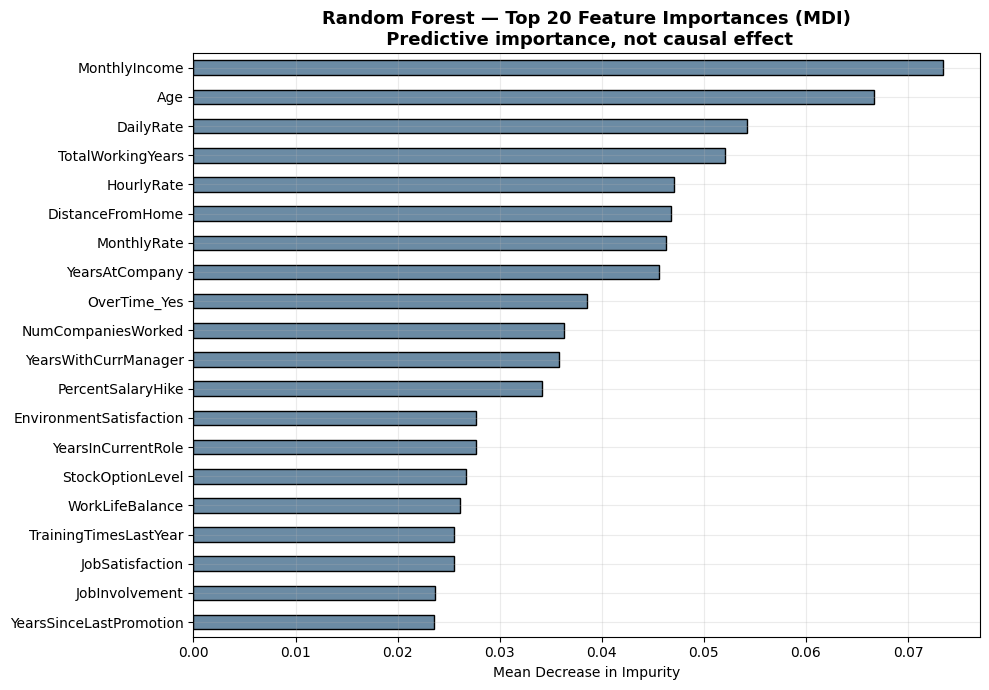


Top 5 features by MDI:
  MonthlyIncome                       0.0734
  Age                                 0.0667
  DailyRate                           0.0542
  TotalWorkingYears                   0.0520
  HourlyRate                          0.0471


In [23]:
# Feature Importance MDI

mdi_importance = pd.Series(
    rf.feature_importances_, index=X_train.columns
).sort_values(ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(10, 7))
mdi_importance.plot.barh(ax=ax, color='#6B8BA4', edgecolor='black')
ax.set_title('Random Forest — Top 20 Feature Importances (MDI)\n Predictive importance, not causal effect',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Mean Decrease in Impurity')
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print('\nTop 5 features by MDI:')
for feat, val in mdi_importance.sort_values(ascending=False).head(5).items():
    print(f'  {feat:<35s} {val:.4f}')

The Random Forest MDI plot is included as an exploratory comparison with the second model. Because Logistic Regression outperforms Random Forest on the held-out test metrics and cross-validated F1-score, the Logistic Regression coefficient plot should be treated as the primary interpretation of the selected model.

The Random Forest importance ranking is still useful as a robustness check because it shows whether a more flexible nonlinear model identifies similar predictive signals. However, MDI importance can favor continuous variables or variables with many possible split points, so these rankings should not be treated as causal effects or definitive policy levers.

### Final Notebook Conclusion

This project predicts voluntary employee attrition using demographic, compensation, satisfaction, workload, and tenure-related features. The dataset is complete, but the target variable is imbalanced, with only about 16% of employees leaving. For that reason, recall and F1-score are more informative than accuracy alone.

Across the held-out test set and 5-fold cross-validation, Logistic Regression performs better than Random Forest. Logistic Regression is therefore selected as the preferred model. However, its recall remains limited, so the model should be used as a risk-screening tool rather than an automatic decision system.

The main business recommendation is for HR to use predicted attrition risk to prioritize low-cost, non-punitive retention outreach. The model can help identify employees or segments that may benefit from manager check-ins, workload review, career-development conversations, or compensation review. These recommendations should be treated as prediction-based guidance, not causal proof that changing any single feature will reduce attrition.